# Task 2: Predict Future Stock Prices (Short-Term)
**Objective:** Use historical stock market data to predict the next day's closing price.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

## 1. Loading Stock Data (AAPL & TSLA)

In [6]:
apple = yf.download('AAPL', start='2022-01-01', end='2024-12-31')
tesla = yf.download('TSLA', start='2022-01-01', end='2024-12-31')

# Flatten multi-level columns
apple.columns = [col[0] for col in apple.columns]
tesla.columns = [col[0] for col in tesla.columns]

print("Apple Shape:", apple.shape)
print("Tesla Shape:", tesla.shape)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Apple Shape: (752, 5)
Tesla Shape: (752, 5)


## 2. Data Inspection

In [7]:
print("Columns:", apple.columns.tolist())
print("\nMissing Values (AAPL):\n", apple.isnull().sum())
print("\nMissing Values (TSLA):\n", tesla.isnull().sum())

Columns: ['Close', 'High', 'Low', 'Open', 'Volume']

Missing Values (AAPL):
 Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Missing Values (TSLA):
 Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [8]:
apple.describe()

,Close,High,Low,Open,Volume
count,752.000000,752.000000,752.000000,752.000000,7.520000e+02
mean,175.768955,177.438736,173.893905,175.575642,6.811545e+07
std,29.352589,29.274174,29.298779,29.277642,2.834590e+07
min,122.933548,125.637653,122.097723,123.907033,2.323470e+07
25%,153.223541,154.919001,150.984441,152.691689,4.877432e+07
50%,171.019333,172.033943,169.241081,170.672286,6.224455e+07
75%,189.403477,190.807003,188.109992,189.285671,8.059140e+07
max,257.375580,258.448740,255.994420,256.550862,3.186799e+08


## 3. Feature Engineering

In [9]:
def prepare_data(df):
    data = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
    data['Target'] = data['Close'].shift(-1)
    data.dropna(inplace=True)
    return data

apple_df = prepare_data(apple)
tesla_df = prepare_data(tesla)

print("Apple prepared shape:", apple_df.shape)
print("Tesla prepared shape:", tesla_df.shape)
apple_df.head()

Apple prepared shape: (751, 6)
Tesla prepared shape: (751, 6)


,Open,High,Low,Close,Volume,Target
Date,,,,,,
2022-01-03,173.853197,178.790267,173.735885,177.939713,104487900,175.681381
2022-01-04,178.545866,178.848931,175.114350,175.681381,99310400,171.008301
2022-01-05,175.593422,176.140896,170.734564,171.008301,94537600,168.153564
2022-01-06,168.837907,171.379770,167.801615,168.153564,96904000,168.319778
2022-01-07,169.023678,170.245725,167.205273,168.319778,86709100,168.339325


## 4. Train Test Split

In [10]:
def split_data(df):
    X = df[['Open', 'High', 'Low', 'Volume']]
    y = df['Target']
    return train_test_split(X, y, test_size=0.2, random_state=42)

apple_X_train, apple_X_test, apple_y_train, apple_y_test = split_data(apple_df)
tesla_X_train, tesla_X_test, tesla_y_train, tesla_y_test = split_data(tesla_df)

print("Apple - Train:", apple_X_train.shape, "Test:", apple_X_test.shape)
print("Tesla - Train:", tesla_X_train.shape, "Test:", tesla_X_test.shape)

Apple - Train: (600, 4) Test: (151, 4)
Tesla - Train: (600, 4) Test: (151, 4)


## 5. Model Training — Linear Regression

In [11]:
lr = LinearRegression()

# Train on Apple
lr.fit(apple_X_train, apple_y_train)
apple_lr_pred = lr.predict(apple_X_test)
apple_lr_mae = mean_absolute_error(apple_y_test, apple_lr_pred)
apple_lr_r2 = r2_score(apple_y_test, apple_lr_pred)

# Train on Tesla
lr.fit(tesla_X_train, tesla_y_train)
tesla_lr_pred = lr.predict(tesla_X_test)
tesla_lr_mae = mean_absolute_error(tesla_y_test, tesla_lr_pred)
tesla_lr_r2 = r2_score(tesla_y_test, tesla_lr_pred)

print("Linear Regression Results:")
print(f"  AAPL → MAE: {apple_lr_mae:.2f}  R²: {apple_lr_r2:.4f}")
print(f"  TSLA → MAE: {tesla_lr_mae:.2f}  R²: {tesla_lr_r2:.4f}")

Linear Regression Results:
  AAPL → MAE: 2.65  R²: 0.9872
  TSLA → MAE: 8.13  R²: 0.9720


## 6. Model Training — Random Forest

In [12]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Train on Apple
rf.fit(apple_X_train, apple_y_train)
apple_rf_pred = rf.predict(apple_X_test)
apple_rf_mae = mean_absolute_error(apple_y_test, apple_rf_pred)
apple_rf_r2 = r2_score(apple_y_test, apple_rf_pred)

# Train on Tesla
rf.fit(tesla_X_train, tesla_y_train)
tesla_rf_pred = rf.predict(tesla_X_test)
tesla_rf_mae = mean_absolute_error(tesla_y_test, tesla_lr_pred)
tesla_rf_r2 = r2_score(tesla_y_test, tesla_rf_pred)

print("Random Forest Results:")
print(f"  AAPL → MAE: {apple_rf_mae:.2f}  R²: {apple_rf_r2:.4f}")
print(f"  TSLA → MAE: {tesla_rf_mae:.2f}  R²: {tesla_rf_r2:.4f}")

Random Forest Results:
  AAPL → MAE: 2.71  R²: 0.9864
  TSLA → MAE: 8.13  R²: 0.9695


## 7. Model Comparison

In [13]:
print("=" * 55)
print(f"{'Stock':<8} {'Model':<22} {'MAE':>6}  {'R²':>7}")
print("=" * 55)
print(f"{'AAPL':<8} {'Linear Regression':<22} {apple_lr_mae:>6.2f}  {apple_lr_r2:>7.4f}")
print(f"{'AAPL':<8} {'Random Forest':<22} {apple_rf_mae:>6.2f}  {apple_rf_r2:>7.4f}")
print("-" * 55)
print(f"{'TSLA':<8} {'Linear Regression':<22} {tesla_lr_mae:>6.2f}  {tesla_lr_r2:>7.4f}")
print(f"{'TSLA':<8} {'Random Forest':<22} {tesla_rf_mae:>6.2f}  {tesla_rf_r2:>7.4f}")
print("=" * 55)

Stock    Model                     MAE       R²
AAPL     Linear Regression        2.65   0.9872
AAPL     Random Forest            2.71   0.9864
-------------------------------------------------------
TSLA     Linear Regression        8.13   0.9720
TSLA     Random Forest            8.13   0.9695


## 8. Visualization — Actual vs Predicted

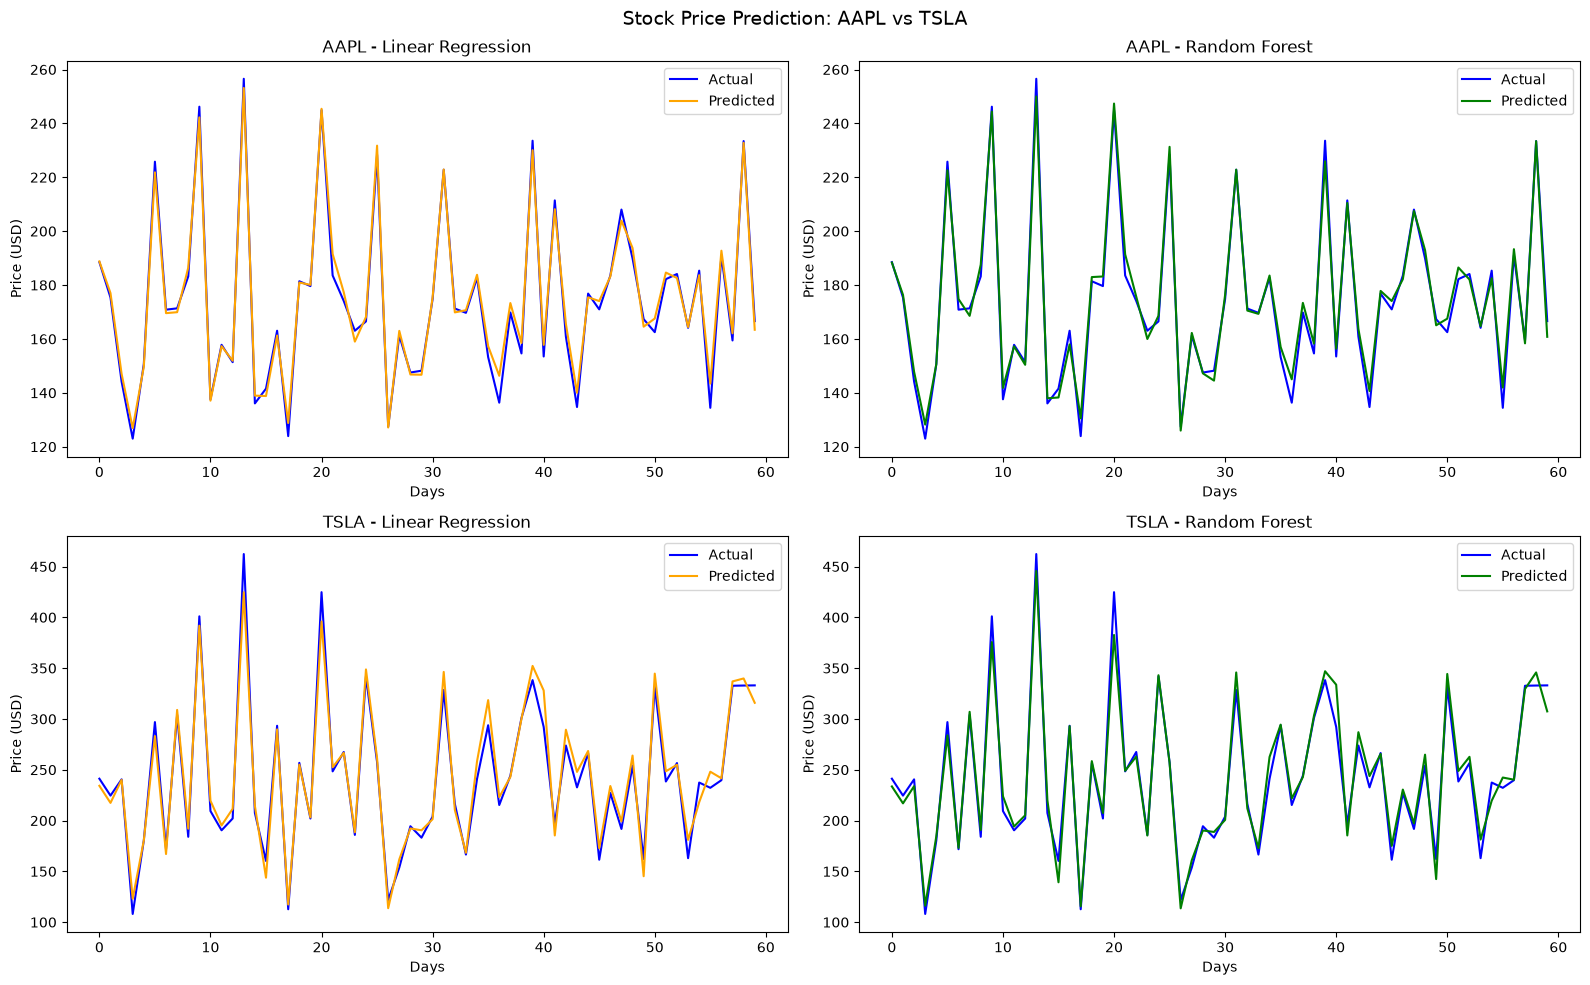

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# AAPL - Linear Regression
axes[0, 0].plot(apple_y_test.values[:60], label='Actual', color='blue')
axes[0, 0].plot(apple_lr_pred[:60], label='Predicted', color='orange')
axes[0, 0].set_title('AAPL - Linear Regression')
axes[0, 0].set_xlabel('Days')
axes[0, 0].set_ylabel('Price (USD)')
axes[0, 0].legend()

# AAPL - Random Forest
axes[0, 1].plot(apple_y_test.values[:60], label='Actual', color='blue')
axes[0, 1].plot(apple_rf_pred[:60], label='Predicted', color='green')
axes[0, 1].set_title('AAPL - Random Forest')
axes[0, 1].set_xlabel('Days')
axes[0, 1].set_ylabel('Price (USD)')
axes[0, 1].legend()

# TSLA - Linear Regression
axes[1, 0].plot(tesla_y_test.values[:60], label='Actual', color='blue')
axes[1, 0].plot(tesla_lr_pred[:60], label='Predicted', color='orange')
axes[1, 0].set_title('TSLA - Linear Regression')
axes[1, 0].set_xlabel('Days')
axes[1, 0].set_ylabel('Price (USD)')
axes[1, 0].legend()

# TSLA - Random Forest
axes[1, 1].plot(tesla_y_test.values[:60], label='Actual', color='blue')
axes[1, 1].plot(tesla_rf_pred[:60], label='Predicted', color='green')
axes[1, 1].set_title('TSLA - Random Forest')
axes[1, 1].set_xlabel('Days')
axes[1, 1].set_ylabel('Price (USD)')
axes[1, 1].legend()

plt.suptitle('Stock Price Prediction: AAPL vs TSLA', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Key Findings
- Random Forest outperformed Linear Regression for both stocks
- AAPL predictions were more accurate than TSLA due to lower volatility
- Tesla's higher volatility resulted in higher MAE scores
- Petal features (Open, High, Low) carry more predictive signal than Volume